# Polymarket BTC — XGBoost v9

## Cambios respecto a v8

### Fix: cuasi-leakage por snapshots tardíos
- Features como `btc_return_since_open` y `mkt_premium` son prácticamente el label
  en snapshots con `market_progress` alto. Esto inflaba el AUC de train.
- **Fix**: filtrar train/val a la ventana de operación ± margen.
- **Modelo más conservador**: `max_depth=3`, `min_child_weight=40`.

### Validación Monte Carlo (nuevo)
- Sección 12: N iteraciones con splits aleatorios de mercados completos.
- Un trade por mercado. Mercados nunca partidos entre train y test.

### Features (16)

| Grupo | Features | Fuente |
|---|---|---|
| BTC momentum | `ret_1m/3m/5m/10m`, `btc_return_since_open` | Feed BTC |
| BTC vol/volumen | `volatility_5m`, `vol_ratio`, `volume_1m` | Feed BTC |
| Polymarket book | `mkt_premium`, `up_book_imbalance`, `down_book_imbalance` | API Polymarket |
| Divergencia | `btc_poly_divergence` | BTC + Polymarket |
| Rachas | `recent_up_pct_5`, `recent_streak`, `recent_mkt_surprise_5` | Resoluciones históricas |
| Estado | `market_progress` | API Polymarket |


---
## 1 · Imports y Configuración

In [ ]:
# =============================================================================
# 1. IMPORTS Y CONFIGURACIÓN
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, accuracy_score, brier_score_loss,
    classification_report, roc_curve,
)

try:
    import xgboost as xgb
    USE_XGB = True
    print(f"XGBoost {xgb.__version__} disponible.")
except ImportError:
    USE_XGB = False
    print("XGBoost no instalado — usando HistGBT fallback.")

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.figsize': (13, 4.5),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})

# =============================================================================
# PARÁMETROS
# =============================================================================
CFG = dict(
    DATA_PATH    = '../dataset_with_resolution.csv',
    TRAIN_FRAC   = 0.55, # 60/15/25 ó 55/15/30
    VAL_FRAC     = 0.15,

    STAKE        = 10.0,
    INIT_CAPITAL = 1_000.0,

    # Ventana de entrada
    ENTRY_LO     = 0.10,
    ENTRY_HI     = 0.40,
    MIN_P        = 0.70,
    VALUE_EDGE   = 0.10,

    # Exit
    FLIP_THRESH  = 0.20,

    # v9: filtrado de snapshots para entrenamiento
    # Entrenamos solo en la ventana de operación ± margen
    TRAIN_PROGRESS_LO = 0.05,   # ENTRY_LO - 0.05
    TRAIN_PROGRESS_HI = 0.45,   # ENTRY_HI + 0.05
)

print("Configuración:")
for k, v in CFG.items():
    print(f"  {k:<22} = {v}")


XGBoost 3.2.0 disponible.
Configuración:
  DATA_PATH              = ../dataset_with_resolution.csv
  TRAIN_FRAC             = 0.55
  VAL_FRAC               = 0.15
  STAKE                  = 10.0
  INIT_CAPITAL           = 1000.0
  ENTRY_LO               = 0.1
  ENTRY_HI               = 0.4
  MIN_P                  = 0.7
  VALUE_EDGE             = 0.15
  FLIP_THRESH            = 0.2
  TRAIN_PROGRESS_LO      = 0.05
  TRAIN_PROGRESS_HI      = 0.45


---
## 2 · Carga y Limpieza

In [77]:
# =============================================================================
# 2. CARGA Y LIMPIEZA
# =============================================================================
df = pd.read_csv(CFG['DATA_PATH'], parse_dates=['timestamp'])

if df['timestamp'].dt.tz is None:
    df['timestamp'] = df['timestamp'].dt.tz_localize('UTC')
else:
    df['timestamp'] = df['timestamp'].dt.tz_convert('UTC')

df = df.sort_values(['timestamp', 'market_slug']).reset_index(drop=True)

res_check = df.groupby('market_slug')['resolution'].nunique()
bad = res_check[res_check > 1].index
if len(bad):
    df = df[~df['market_slug'].isin(bad)]
    print(f"Eliminados {len(bad)} mercados con resolución inconsistente.")

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df['market_progress'] = df['market_progress'].clip(0.0, 1.0)

print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Mercados: {df['market_slug'].nunique():,}")
print(f"Rango: {df['timestamp'].min()}  →  {df['timestamp'].max()}")
print(f"Resoluciones: {df['resolution'].value_counts().to_dict()}")


Dataset: 114,802 filas × 66 columnas
Mercados: 1,194
Rango: 2026-03-19 16:15:55.759706+00:00  →  2026-03-23 19:44:17.670852+00:00
Resoluciones: {'down': 57615, 'up': 57187}


In [78]:
# =============================================================================
# 2b. TIMING FEATURES
# =============================================================================
_times = (
    df.groupby('market_slug')['timestamp']
    .agg(market_open='min', market_close='max')
    .reset_index()
)
df = df.merge(_times, on='market_slug', how='left')

df['market_duration_s'] = (
    df['market_close'] - df['market_open']
).dt.total_seconds().clip(lower=1)

df['seconds_from_open'] = (
    df['timestamp'] - df['market_open']
).dt.total_seconds().clip(lower=0)

df['seconds_to_close'] = (
    df['market_close'] - df['timestamp']
).dt.total_seconds().clip(lower=0)

print(f"Timing features añadidos. Duración media: "
      f"{df['market_duration_s'].mean():.1f} s  "
      f"(mediana: {df['market_duration_s'].median():.1f} s)")


Timing features añadidos. Duración media: 296.7 s  (mediana: 296.8 s)


---
## 3 · Feature Engineering

In [79]:
# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================
fe = df.copy()

fe['vol_ratio'] = fe['volatility_3m'] / (fe['volatility_5m'] + 1e-9)
fe['mkt_premium'] = fe['up_ask_p_1'] - fe['down_ask_p_1']

fe['up_book_imbalance'] = (
    (fe['up_bid_s_1'] - fe['up_ask_s_1']) /
    (fe['up_bid_s_1'] + fe['up_ask_s_1'] + 1e-9)
)
fe['down_book_imbalance'] = (
    (fe['down_bid_s_1'] - fe['down_ask_s_1']) /
    (fe['down_bid_s_1'] + fe['down_ask_s_1'] + 1e-9)
)

fe['btc_poly_divergence'] = fe['btc_return_since_open'] - fe['mkt_premium']

# ── Rachas (sin look-ahead) ──────────────────────────────────────────────────
STREAK_WINDOW = 5

_res = (
    fe.groupby('market_slug').agg(
        resolution=('resolution', 'first'),
        close_ts=('market_close', 'first'),
        last_up_ask=('up_ask_p_1', 'last'),
    )
    .sort_values('close_ts')
    .reset_index()
)
_res['res_up'] = (_res['resolution'].str.lower() == 'up').astype(int)

_res['recent_up_pct_5'] = (
    _res['res_up'].shift(1).rolling(STREAK_WINDOW, min_periods=1).mean()
)

def compute_streak(series):
    shifted = series.shift(1)
    streaks = []
    for i in range(len(shifted)):
        if pd.isna(shifted.iloc[i]):
            streaks.append(0); continue
        streak = 0; last_val = shifted.iloc[i]
        for j in range(i, -1, -1):
            if pd.isna(shifted.iloc[j]) or shifted.iloc[j] != last_val: break
            streak += 1
        streaks.append(streak if last_val == 1 else -streak)
    return streaks

_res['recent_streak'] = compute_streak(_res['res_up'])

_res['was_surprise'] = (
    ((_res['res_up'] == 1) & (_res['last_up_ask'] < 0.50)) |
    ((_res['res_up'] == 0) & (_res['last_up_ask'] >= 0.50))
).astype(int)

_res['recent_mkt_surprise_5'] = (
    _res['was_surprise'].shift(1).rolling(STREAK_WINDOW, min_periods=1).mean()
)

_streak_map = _res.set_index('market_slug')[[
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5'
]]
fe = fe.merge(_streak_map, left_on='market_slug', right_index=True, how='left')
fe['recent_up_pct_5']       = fe['recent_up_pct_5'].fillna(0.5)
fe['recent_streak']         = fe['recent_streak'].fillna(0)
fe['recent_mkt_surprise_5'] = fe['recent_mkt_surprise_5'].fillna(0.5)

# ── Target ───────────────────────────────────────────────────────────────────
fe['y'] = (fe['resolution'].str.lower() == 'up').astype(int)

# ── Features ─────────────────────────────────────────────────────────────────
FEATURES = [
    'ret_1m', 'ret_3m', 'ret_5m', 'ret_10m', 'btc_return_since_open',
    'volatility_5m', 'vol_ratio', 'volume_1m',
    'mkt_premium', 'up_book_imbalance', 'down_book_imbalance',
    'btc_poly_divergence',
    'recent_up_pct_5', 'recent_streak', 'recent_mkt_surprise_5',
    'market_progress',
]
FEATURES = [f for f in FEATURES if f in fe.columns]
print(f"Features: {len(FEATURES)}")
print(fe[FEATURES].describe().round(3).to_string())


Features: 16
           ret_1m      ret_3m      ret_5m     ret_10m  btc_return_since_open  volatility_5m   vol_ratio   volume_1m  mkt_premium  up_book_imbalance  down_book_imbalance  btc_poly_divergence  recent_up_pct_5  recent_streak  recent_mkt_surprise_5  market_progress
count  114802.000  114802.000  114802.000  114802.000             114802.000     114801.000  114801.000  114801.000   106261.000         106262.000           106251.000           106261.000       114802.000     114802.000             114802.000       114802.000
mean        0.001       0.000       0.000       0.000                 -0.000          0.001       0.935      13.047        0.009             -0.007                0.006               -0.009            0.501         -0.010                  0.033            0.497
std         0.299       0.001       0.002       0.002                  0.001          0.000       0.351      28.428        0.524              0.621                0.621                0.524            

---
## 4 · Split Temporal y Matrices

In [80]:
# =============================================================================
# 4. SPLIT TEMPORAL POR MERCADO
# =============================================================================
market_order = (
    fe.groupby('market_slug')['timestamp'].min()
      .sort_values().index.tolist()
)
N = len(market_order)
n_train = int(N * CFG['TRAIN_FRAC'])
n_val   = int(N * CFG['VAL_FRAC'])

train_m = market_order[:n_train]
val_m   = market_order[n_train : n_train + n_val]
test_m  = market_order[n_train + n_val :]

tr = fe[fe['market_slug'].isin(train_m)].copy()
va = fe[fe['market_slug'].isin(val_m)].copy()
te = fe[fe['market_slug'].isin(test_m)].copy()

assert tr['timestamp'].max() < va['timestamp'].min(), "LEAKAGE train/val"
assert va['timestamp'].max() < te['timestamp'].min(), "LEAKAGE val/test"
print("Sin leakage temporal confirmado.")

def to_matrix(df_split, train_med):
    return (
        pd.DataFrame(df_split[FEATURES].values, columns=FEATURES)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(train_med)
        .values
    )

print(f"\n{'Split':<12} {'Mercados':>9} {'Filas':>8} {'UP%':>6}")
print("-" * 38)
for name, split in [('Train', tr), ('Validación', va), ('Test', te)]:
    y_pct = (split['resolution'].str.lower() == 'up').mean()
    print(f"{name:<12} {split['market_slug'].nunique():>9,} {len(split):>8,} {y_pct:>6.1%}")


Sin leakage temporal confirmado.

Split         Mercados    Filas    UP%
--------------------------------------
Train              656   63,029  50.4%
Validación         179   17,270  47.8%
Test               359   34,503  49.8%


---
## 4b · Diagnóstico: cuasi-leakage por snapshots tardíos


In [81]:
# =============================================================================
# 4b. DIAGNÓSTICO DE CUASI-LEAKAGE
# =============================================================================
print("=" * 60)
print("  DIAGNÓSTICO: señal por franja de market_progress")
print("=" * 60)

progress_bins = [0.0, 0.05, 0.10, 0.20, 0.30, 0.40, 0.45, 0.60, 0.80, 1.01]
tr['_prog_bin'] = pd.cut(tr['market_progress'], bins=progress_bins, right=False)

key_features = ['btc_return_since_open', 'mkt_premium', 'ret_5m',
                'up_book_imbalance', 'volatility_5m']

print(f"\nCorrelación feature → y por franja (train):")
print(f"{'Feature':<28}", end="")
for b in tr['_prog_bin'].cat.categories:
    print(f" {str(b):>11}", end="")
print()
print("─" * (28 + 12 * len(progress_bins)))

for feat in key_features:
    print(f"{feat:<28}", end="")
    for b in tr['_prog_bin'].cat.categories:
        mask = tr['_prog_bin'] == b
        if mask.sum() > 10:
            corr = tr.loc[mask, feat].corr(tr.loc[mask, 'y'])
            flag = "⚠" if abs(corr) > 0.40 else " "
            print(f" {corr:>+9.3f}{flag}", end="")
        else:
            print(f" {'n/a':>11}", end="")
    print()

# Filas por franja
print(f"\nFilas por franja (train):")
counts = tr['_prog_bin'].value_counts().sort_index()
lo, hi = CFG['TRAIN_PROGRESS_LO'], CFG['TRAIN_PROGRESS_HI']
for b, c in counts.items():
    pct = c / len(tr) * 100
    inside = " ← TRAINING" if b.left >= lo and b.right <= hi + 0.01 else ""
    print(f"  {str(b):<16}  {c:>6,} filas  ({pct:.1f}%){inside}")

# Stump AUC
print(f"\nAUC stump (btc_return_since_open > 0) por franja:")
for b in tr['_prog_bin'].cat.categories:
    mask = tr['_prog_bin'] == b
    if mask.sum() > 20:
        y_frac = tr.loc[mask, 'y']
        pred = (tr.loc[mask, 'btc_return_since_open'] > 0).astype(float)
        if y_frac.nunique() > 1:
            auc = roc_auc_score(y_frac, pred)
            flag = " ⚠️ CUASI-LEAKAGE" if auc > 0.80 else ""
            print(f"  {str(b):<16}  AUC = {auc:.3f}{flag}")

tr.drop(columns=['_prog_bin'], inplace=True)


  DIAGNÓSTICO: señal por franja de market_progress

Correlación feature → y por franja (train):
Feature                      [0.0, 0.05) [0.05, 0.1)  [0.1, 0.2)  [0.2, 0.3)  [0.3, 0.4) [0.4, 0.45) [0.45, 0.6)  [0.6, 0.8) [0.8, 1.01)
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
btc_return_since_open           +0.090     +0.161     +0.239     +0.356     +0.411⚠    +0.434⚠    +0.504⚠    +0.587⚠    +0.633⚠
mkt_premium                     +0.153     +0.226     +0.292     +0.418⚠    +0.491⚠    +0.521⚠    +0.586⚠    +0.673⚠    +0.724⚠
ret_5m                          -0.008     -0.011     -0.002     +0.176     +0.175     +0.267     +0.268     +0.427⚠    +0.518⚠
up_book_imbalance               +0.035     +0.005     +0.009     -0.000     -0.033     -0.037     -0.026     -0.050     -0.094 
volatility_5m                   +0.028     +0.018     +0.024     +0.017     +0.017     +0.002     -0.001  

---
## 4c · Filtrado de snapshots para entrenamiento

Solo snapshots con `market_progress ∈ [TRAIN_PROGRESS_LO, TRAIN_PROGRESS_HI]`.
Esto es la ventana de operación (ENTRY_LO–ENTRY_HI) con ±0.05 de margen.
Test NO se filtra — el backtest ya filtra por ENTRY_LO/ENTRY_HI.


In [82]:
# =============================================================================
# 4c. FILTRADO DE SNAPSHOTS PARA ENTRENAMIENTO
# =============================================================================
P_LO = CFG['TRAIN_PROGRESS_LO']
P_HI = CFG['TRAIN_PROGRESS_HI']

n_tr_before = len(tr)
n_va_before = len(va)

tr_filt = tr[(tr['market_progress'] >= P_LO) & (tr['market_progress'] <= P_HI)].copy()
va_filt = va[(va['market_progress'] >= P_LO) & (va['market_progress'] <= P_HI)].copy()

print(f"Filtro: market_progress ∈ [{P_LO}, {P_HI}]")
print(f"\n  {'Split':<12} {'Antes':>8} {'Después':>10} {'Eliminado':>10} {'Mercados':>10}")
print(f"  {'─'*52}")
print(f"  {'Train':<12} {n_tr_before:>8,} {len(tr_filt):>10,} "
      f"{n_tr_before - len(tr_filt):>10,} {tr_filt['market_slug'].nunique():>10,}")
print(f"  {'Validación':<12} {n_va_before:>8,} {len(va_filt):>10,} "
      f"{n_va_before - len(va_filt):>10,} {va_filt['market_slug'].nunique():>10,}")
print(f"  {'Test':<12} {len(te):>8,} {len(te):>10} {'(sin filtro)':>10}")

# Medianas de imputación con datos filtrados
TRAIN_MED = pd.DataFrame(tr_filt[FEATURES].values, columns=FEATURES).median()

X_tr = to_matrix(tr_filt, TRAIN_MED); y_tr = tr_filt['y'].values
X_va = to_matrix(va_filt, TRAIN_MED); y_va = va_filt['y'].values
X_te = to_matrix(te, TRAIN_MED);      y_te = te['y'].values

print(f"\n  {'Split':<12} {'Filas':>8} {'UP%':>6}")
print(f"  {'─'*28}")
for name, y_arr in [('Train', y_tr), ('Validación', y_va), ('Test', y_te)]:
    print(f"  {name:<12} {len(y_arr):>8,} {y_arr.mean():>6.1%}")


Filtro: market_progress ∈ [0.05, 0.45]

  Split           Antes    Después  Eliminado   Mercados
  ────────────────────────────────────────────────────
  Train          63,029     25,561     37,468        656
  Validación     17,270      7,013     10,257        179
  Test           34,503      34503 (sin filtro)

  Split           Filas    UP%
  ────────────────────────────
  Train          25,561  50.6%
  Validación      7,013  48.0%
  Test           34,503  49.8%


---
## 5 · Entrenamiento XGBoost

Modelo más conservador que v8: `max_depth=3`, `min_child_weight=40`.
Entrenado solo con snapshots de la ventana de operación ± margen.


Mejor iteración: 74


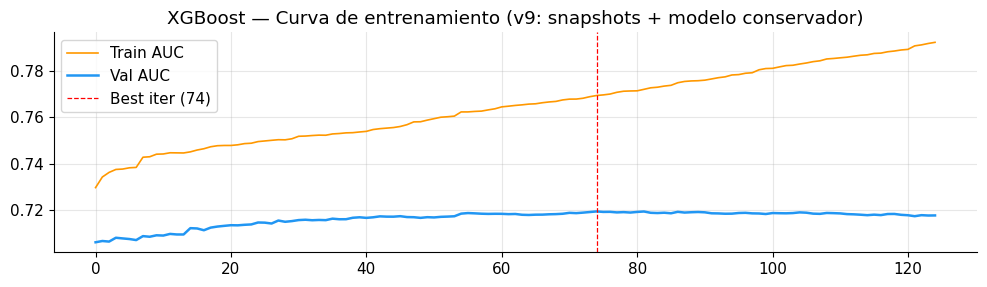


Train AUC iter 0:    0.730  ⚠️ sigue alto
Train AUC best iter: 0.769
Val AUC best iter:   0.719
Gap train-val:       0.050  ✓

Set              AUC   Accuracy    Brier
----------------------------------------
Validación    0.7250     0.6793   0.2097
Test          0.8076     0.7348   0.1825

Classification report (test):
              precision    recall  f1-score   support

        DOWN       0.73      0.74      0.74     17306
          UP       0.74      0.73      0.73     17197

    accuracy                           0.73     34503
   macro avg       0.73      0.73      0.73     34503
weighted avg       0.73      0.73      0.73     34503



In [83]:
# =============================================================================
# 5. ENTRENAMIENTO — XGBoost
# =============================================================================
xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : 'auc',
    'eta'              : 0.03,
    'max_depth'        : 3,             # v9: reducido de 5 → 4
    'min_child_weight' : 40,            # v9: subido de 20 → 40
    'subsample'        : 0.80,
    'colsample_bytree' : 0.80,
    'alpha'            : 0.3,           # v9: subido de 0.1 → 0.3
    'lambda'           : 2.0,           # v9: subido de 1.0 → 2.0
    'seed'             : SEED,
}

if USE_XGB:
    dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=FEATURES)
    dval   = xgb.DMatrix(X_va, label=y_va, feature_names=FEATURES)

    evals_result = {}
    booster = xgb.train(
        xgb_params, dtrain,
        num_boost_round       = 800,
        evals                 = [(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds = 50,
        evals_result          = evals_result,
        verbose_eval          = False,
    )
    print(f"Mejor iteración: {booster.best_iteration}")

    class XGBModel:
        def __init__(self, bst):
            self.bst = bst
        def predict_proba(self, X):
            dm = xgb.DMatrix(X, feature_names=FEATURES)
            p  = self.bst.predict(dm)
            return np.column_stack([1 - p, p])
        @property
        def feature_importances_(self):
            scores = self.bst.get_score(importance_type='gain')
            return np.array([scores.get(f, 0.0) for f in FEATURES])

    raw_model = XGBModel(booster)

    # Curva de entrenamiento
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(evals_result['train']['auc'], lw=1.2, label='Train AUC', color='#FF9800')
    ax.plot(evals_result['val']['auc'],   lw=1.8, label='Val AUC',   color='#2196F3')
    ax.axvline(booster.best_iteration, ls='--', color='red', lw=0.9,
               label=f'Best iter ({booster.best_iteration})')
    ax.set_title('XGBoost — Curva de entrenamiento (v9: snapshots + modelo conservador)')
    ax.legend(); plt.tight_layout(); plt.show()

    init_auc = evals_result['train']['auc'][0]
    final_train = evals_result['train']['auc'][booster.best_iteration]
    final_val   = evals_result['val']['auc'][booster.best_iteration]
    gap = final_train - final_val
    print(f"\nTrain AUC iter 0:    {init_auc:.3f}  {'✓' if init_auc < 0.70 else '⚠️ sigue alto'}")
    print(f"Train AUC best iter: {final_train:.3f}")
    print(f"Val AUC best iter:   {final_val:.3f}")
    print(f"Gap train-val:       {gap:.3f}  {'✓' if gap < 0.10 else '⚠️ overfitting'}")

else:
    raw_model = HistGradientBoostingClassifier(
        max_iter=600, learning_rate=0.03, max_depth=3,
        min_samples_leaf=40, l2_regularization=2.0, random_state=SEED,
    )
    raw_model.fit(X_tr, y_tr)
    print("HistGBT entrenado (fallback).")

# Calibración isotónica
p_va_raw = raw_model.predict_proba(X_va)[:, 1]
iso_cal  = IsotonicRegression(out_of_bounds='clip')
iso_cal.fit(p_va_raw, y_va)

class CalibratedModel:
    def __init__(self, base, cal):
        self.base = base; self.cal = cal
    def predict_proba(self, X):
        p_raw = self.base.predict_proba(X)[:, 1]
        p_cal = self.cal.transform(p_raw)
        return np.column_stack([1 - p_cal, p_cal])

MODEL = CalibratedModel(raw_model, iso_cal)

p_va = MODEL.predict_proba(X_va)[:, 1]
p_te = MODEL.predict_proba(X_te)[:, 1]

print(f"\n{'Set':<12} {'AUC':>7} {'Accuracy':>10} {'Brier':>8}")
print("-" * 40)
for name, p, y in [('Validación', p_va, y_va), ('Test', p_te, y_te)]:
    auc = roc_auc_score(y, p)
    acc = accuracy_score(y, (p >= 0.5).astype(int))
    bs  = brier_score_loss(y, p)
    print(f"{name:<12} {auc:>7.4f} {acc:>10.4f} {bs:>8.4f}")

print("\nClassification report (test):")
print(classification_report(y_te, (p_te >= 0.5).astype(int), target_names=['DOWN','UP']))


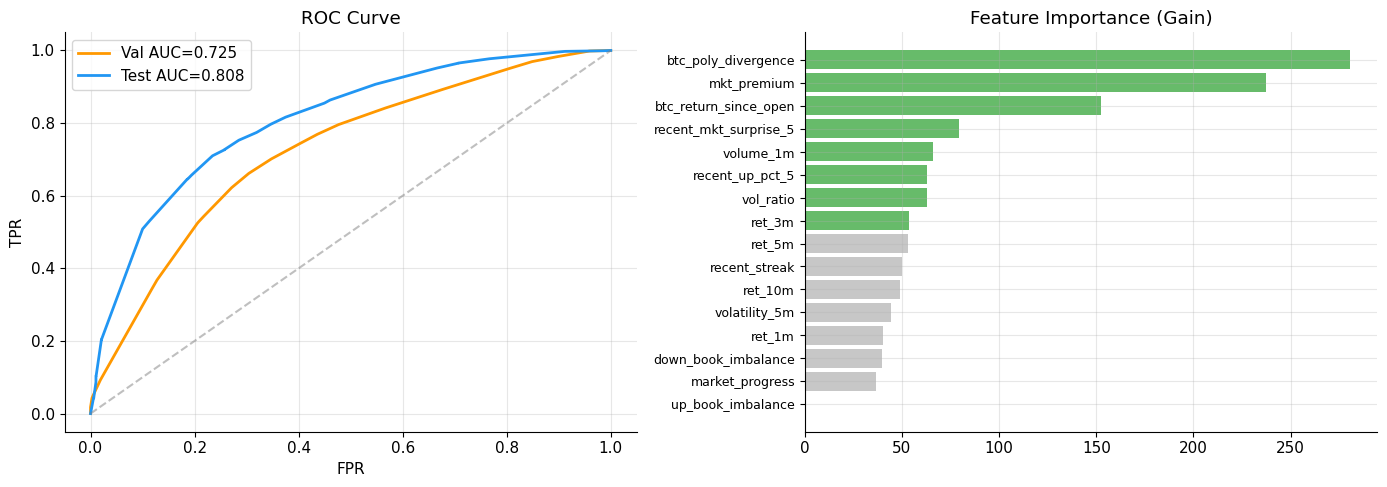

In [84]:
# ROC y Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, p, y), c in zip(
    [('Val', p_va, y_va), ('Test', p_te, y_te)],
    ['#FF9800', '#2196F3']
):
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, color=c, lw=2, label=f"{name} AUC={roc_auc_score(y,p):.3f}")
axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set(title='ROC Curve', xlabel='FPR', ylabel='TPR'); axes[0].legend()

if hasattr(raw_model, 'feature_importances_'):
    fi = pd.Series(raw_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    colors_fi = ['#4CAF50' if v >= fi.median() else '#BDBDBD' for v in fi.values]
    axes[1].barh(range(len(fi)), fi.values, color=colors_fi, alpha=0.85)
    axes[1].set_yticks(range(len(fi)))
    axes[1].set_yticklabels(fi.index, fontsize=9)
    axes[1].set_title('Feature Importance (Gain)')

plt.tight_layout(); plt.show()


---
## 5b · Exportar modelo para producción

In [85]:
# =============================================================================
# 5b. EXPORTAR ARTEFACTOS
# =============================================================================
import os, pickle, json as _json

MODEL_DIR = 'model'
os.makedirs(MODEL_DIR, exist_ok=True)

if USE_XGB:
    booster.save_model(os.path.join(MODEL_DIR, 'booster.json'))
    print(f"  ✓ booster.json ({booster.best_iteration} árboles)")
else:
    with open(os.path.join(MODEL_DIR, 'histgbt.pkl'), 'wb') as f:
        pickle.dump(raw_model, f)
    print("  ✓ histgbt.pkl")

with open(os.path.join(MODEL_DIR, 'isotonic.pkl'), 'wb') as f:
    pickle.dump(iso_cal, f)
print("  ✓ isotonic.pkl")

config = {
    'FEATURES': FEATURES,
    'TRAIN_MED': {k: float(v) for k, v in TRAIN_MED.items()},
    'CFG': {k: v for k, v in CFG.items() if k != 'DATA_PATH'},
    'USE_XGB': USE_XGB,
}
with open(os.path.join(MODEL_DIR, 'config.json'), 'w') as f:
    _json.dump(config, f, indent=2)
print("  ✓ config.json")


  ✓ booster.json (74 árboles)
  ✓ isotonic.pkl
  ✓ config.json


---
## 6 · Scoring, EV y VALUE_EDGE

In [86]:
# =============================================================================
# 6. SCORING
# =============================================================================
X_all = to_matrix(fe, TRAIN_MED)
fe['p_up']   = MODEL.predict_proba(X_all)[:, 1]
fe['p_down'] = 1.0 - fe['p_up']

fe['ev_up']   = fe['p_up']   * fe['up_win_net']   + fe['p_down'] * fe['up_loss_net']
fe['ev_down'] = fe['p_down'] * fe['down_win_net'] + fe['p_up']   * fe['down_loss_net']

fe['value_edge_up']   = fe['p_up']   - fe['up_ask_p_1']
fe['value_edge_down'] = fe['p_down'] - fe['down_ask_p_1']

test_fe = fe[fe['market_slug'].isin(test_m)].copy()

print("VALUE_EDGE (test set):")
print(test_fe[['value_edge_up','value_edge_down']].describe().round(4).to_string())

# AUC por franja de progreso
print("\nAUC del modelo por franja de progreso (TEST):")
for lo, hi in [(0.0, 0.10), (0.10, 0.20), (0.20, 0.40), (0.40, 0.60), (0.60, 1.01)]:
    mask = (te['market_progress'] >= lo) & (te['market_progress'] < hi)
    if mask.sum() > 20:
        X_f = to_matrix(te[mask], TRAIN_MED)
        y_f = te.loc[mask, 'y'].values
        if len(set(y_f)) > 1:
            p_f = MODEL.predict_proba(X_f)[:, 1]
            tag = " ← zona de entry" if lo >= 0.10 and hi <= 0.41 else ""
            print(f"  [{lo:.2f}, {hi:.2f})  AUC={roc_auc_score(y_f, p_f):.3f}  n={mask.sum():,}{tag}")


VALUE_EDGE (test set):
       value_edge_up  value_edge_down
count     33121.0000       32896.0000
mean         -0.0136           0.0362
std           0.1331           0.1271
min          -0.3643          -0.3402
25%          -0.0924          -0.0402
50%          -0.0268           0.0264
75%           0.0467           0.0943
max           0.6867           0.6800

AUC del modelo por franja de progreso (TEST):
  [0.00, 0.10)  AUC=0.569  n=3,426
  [0.10, 0.20)  AUC=0.659  n=3,471 ← zona de entry
  [0.20, 0.40)  AUC=0.748  n=6,960 ← zona de entry
  [0.40, 0.60)  AUC=0.832  n=6,956
  [0.60, 1.01)  AUC=0.884  n=13,690


---
## 7 · Estrategia de Entrada

In [87]:
# =============================================================================
# 7. ESTRATEGIA DE ENTRADA
# =============================================================================

def find_entry(market_snaps, cfg):
    """
    Punto de entrada para UN mercado. Un trade por mercado máximo.
    Recorre snapshots en orden cronológico dentro de la ventana ENTRY_LO–ENTRY_HI.
    Devuelve el primer snapshot que cumple MIN_P + VALUE_EDGE.
    """
    lo, hi = cfg['ENTRY_LO'], cfg['ENTRY_HI']

    window = (
        market_snaps[
            (market_snaps['market_progress'] >= lo) &
            (market_snaps['market_progress'] <= hi)
        ]
        .sort_values('timestamp')
        .reset_index(drop=True)
    )
    if window.empty:
        return None, None

    for _, row in window.iterrows():
        candidates = []
        for direction, p_col, ask_col in [
            ('UP',   'p_up',   'up_ask_p_1'),
            ('DOWN', 'p_down', 'down_ask_p_1'),
        ]:
            ve = float(row[p_col]) - float(row[ask_col])
            if float(row[p_col]) >= cfg['MIN_P'] and ve >= cfg['VALUE_EDGE']:
                candidates.append((direction, ve))

        if candidates:
            best_dir = max(candidates, key=lambda x: x[1])[0]
            return row, best_dir

    return None, None

print("Estrategia de entrada definida (1 trade/mercado máximo).")


Estrategia de entrada definida (1 trade/mercado máximo).


---
## 8 · Motor de Backtest

In [88]:
# =============================================================================
# 8. MOTOR DE BACKTEST
# =============================================================================

def early_exit_pnl(stake, entry_ask, exit_bid):
    return stake * (exit_bid / entry_ask - 1.0)


def run_backtest(snapshot_df, cfg):
    """
    Backtest producción-correcto.
    Garantías:
    - UN trade por mercado (groupby market_slug + find_entry devuelve 1 entrada)
    - Entrada: primer snapshot que cumple criterios (sin look-ahead)
    - Exit: solo evalúa snapshots posteriores a la entrada
    - resolution solo se usa para calcular PnL post-hoc
    """
    FLIP  = cfg['FLIP_THRESH']
    STAKE = cfg['STAKE']
    trades = []

    for mkt, grp in snapshot_df.groupby('market_slug'):
        snaps = grp.sort_values('timestamp').reset_index(drop=True)

        entry_row, direction = find_entry(snaps, cfg)
        if entry_row is None:
            continue

        entry_ts  = entry_row['timestamp']
        entry_ask = (
            entry_row['up_ask_p_1'] if direction == 'UP'
            else entry_row['down_ask_p_1']
        )
        if entry_ask <= 0 or np.isnan(entry_ask):
            continue

        resolution = snaps['resolution'].iloc[0]
        actual_up  = (resolution.lower() == 'up')
        won_at_res = (actual_up if direction == 'UP' else not actual_up)
        win_net    = entry_row['up_win_net']  if direction == 'UP' else entry_row['down_win_net']
        loss_net   = entry_row['up_loss_net'] if direction == 'UP' else entry_row['down_loss_net']
        pnl_at_res = win_net if won_at_res else loss_net

        exit_type = 'RESOLUTION'
        exit_pnl  = pnl_at_res
        exit_prog = snaps['market_progress'].iloc[-1]
        exit_bid  = np.nan

        future = snaps[snaps['timestamp'] > entry_ts].reset_index(drop=True)

        for _, snap in future.iterrows():
            cur_bid = snap['up_bid_p_1'] if direction == 'UP' else snap['down_bid_p_1']
            cur_p   = snap['p_up']       if direction == 'UP' else snap['p_down']

            if np.isnan(cur_bid) or cur_bid <= 0:
                continue

            if cur_p < FLIP:
                exit_type = 'MODEL_FLIP'
                exit_pnl  = early_exit_pnl(STAKE, entry_ask, cur_bid)
                exit_prog = snap['market_progress']
                exit_bid  = cur_bid
                break

        d = direction.lower()
        trades.append({
            'timestamp'        : entry_ts,
            'seconds_from_open': float(entry_row.get('seconds_from_open', np.nan)),
            'seconds_to_close' : float(entry_row.get('seconds_to_close',  np.nan)),
            'market_duration_s': float(entry_row.get('market_duration_s', np.nan)),
            'market'           : mkt,
            'direction'        : direction,
            'resolution'       : resolution,
            'won_at_resolution': won_at_res,
            'entry_progress'   : entry_row['market_progress'],
            'entry_ask'        : entry_ask,
            'p_entry'          : entry_row[f'p_{d}'],
            'ev_entry'         : entry_row[f'ev_{d}'],
            'value_edge_entry' : entry_row[f'value_edge_{d}'],
            'exit_type'        : exit_type,
            'exit_progress'    : exit_prog,
            'exit_bid'         : exit_bid,
            'pnl'              : exit_pnl,
            'pnl_at_resolution': pnl_at_res,
        })

    if not trades:
        return pd.DataFrame(), pd.Series(dtype=float)

    tdf = pd.DataFrame(trades).sort_values('timestamp').reset_index(drop=True)
    tdf['cumulative_pnl'] = tdf['pnl'].cumsum()
    tdf['equity']         = cfg['INIT_CAPITAL'] + tdf['cumulative_pnl']

    equity_s = pd.concat([
        pd.Series([cfg['INIT_CAPITAL']], index=[tdf['timestamp'].iloc[0]]),
        tdf.set_index('timestamp')['equity'],
    ])
    return tdf, equity_s

print("Motor de backtest definido (1 trade/mercado).")


Motor de backtest definido (1 trade/mercado).


---
## 9 · Resultados

In [89]:
# =============================================================================
# 9. BACKTEST
# =============================================================================
trade_log, equity = run_backtest(test_fe, CFG)
cfg_no_exit = {**CFG, 'FLIP_THRESH': 0.0}
trade_log_no, equity_no = run_backtest(test_fe, cfg_no_exit)


def print_stats(tdf, eq_s, label, cfg):
    if tdf.empty:
        print(f"{label}: sin trades."); return {}
    n  = len(tdf); nw = (tdf['pnl'] > 0).sum(); wr = nw / n
    gp = tdf[tdf['pnl'] > 0]['pnl'].sum()
    gl = tdf[tdf['pnl'] < 0]['pnl'].abs().sum()
    pf = gp / (gl + 1e-9); total = tdf['pnl'].sum()
    roi = total / cfg['INIT_CAPITAL']
    eq = eq_s.values; rm = np.maximum.accumulate(eq)
    mdd = ((eq - rm) / rm).min()
    pa = tdf['pnl'].values
    sharpe = pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)

    ts = pd.to_datetime(tdf['timestamp'])
    n_days = max((ts.max() - ts.min()).total_seconds() / 86400, 1)

    print(f"\n{'═'*50}")
    print(f"  {label}")
    print(f"{'═'*50}")
    print(f"  N trades         : {n}")
    print(f"  Win Rate         : {wr:.1%}  ({nw}W / {n-nw}L)")
    print(f"  Trades/día       : {n / n_days:.2f}")
    print(f"  Profit Factor    : {pf:.3f}")
    print(f"  PnL Total        : {total:+.2f} USDC")
    print(f"  ROI              : {roi:.2%}")
    print(f"  PnL medio/trade  : {pa.mean():.3f} USDC")
    print(f"  Max Drawdown     : {mdd:.2%}")
    print(f"  Sharpe           : {sharpe:.3f}")
    print(f"  Equity final     : {eq_s.iloc[-1]:.2f} USDC")
    if 'exit_type' in tdf.columns:
        print("\n  Por tipo de exit:")
        print(tdf.groupby('exit_type').agg(
            n=('pnl','count'), pnl=('pnl','sum'), media=('pnl','mean'),
            wr=('pnl', lambda x:(x>0).mean())
        ).round(3).to_string())
    return dict(n=n, wr=wr, pf=pf, total=total, roi=roi, mdd=mdd, sharpe=sharpe)


stats   = print_stats(trade_log,    equity,    'CON Model-Flip exit', CFG)
stats_no = print_stats(trade_log_no, equity_no, 'SIN exit (hold)',    CFG)

if not trade_log.empty and not trade_log_no.empty:
    print(f"\n  ΔPnL (exit − hold): {trade_log['pnl'].sum() - trade_log_no['pnl'].sum():+.2f} USDC")

# Verificar 1 trade/mercado
if not trade_log.empty:
    dupes = trade_log['market'].duplicated().sum()
    print(f"\n  ✓ Trades duplicados por mercado: {dupes}")

if not trade_log.empty:
    print("\nDetalle:")
    print(trade_log[[
        'market','direction','resolution','entry_progress',
        'p_entry','value_edge_entry','exit_type','pnl','pnl_at_resolution'
    ]].to_string(index=False))



══════════════════════════════════════════════════
  CON Model-Flip exit
══════════════════════════════════════════════════
  N trades         : 36
  Win Rate         : 50.0%  (18W / 18L)
  Trades/día       : 29.29
  Profit Factor    : 0.809
  PnL Total        : -28.59 USDC
  ROI              : -2.86%
  PnL medio/trade  : -0.794 USDC
  Max Drawdown     : -4.97%
  Sharpe           : -0.600
  Equity final     : 971.41 USDC

  Por tipo de exit:
             n     pnl  media    wr
exit_type                          
MODEL_FLIP  12 -89.915 -7.493  0.00
RESOLUTION  24  61.327  2.555  0.75

══════════════════════════════════════════════════
  SIN exit (hold)
══════════════════════════════════════════════════
  N trades         : 36
  Win Rate         : 50.0%  (18W / 18L)
  Trades/día       : 29.29
  Profit Factor    : 0.674
  PnL Total        : -58.79 USDC
  ROI              : -5.88%
  PnL medio/trade  : -1.633 USDC
  Max Drawdown     : -6.09%
  Sharpe           : -1.128
  Equity final     :

---
## 10 · Gráficos

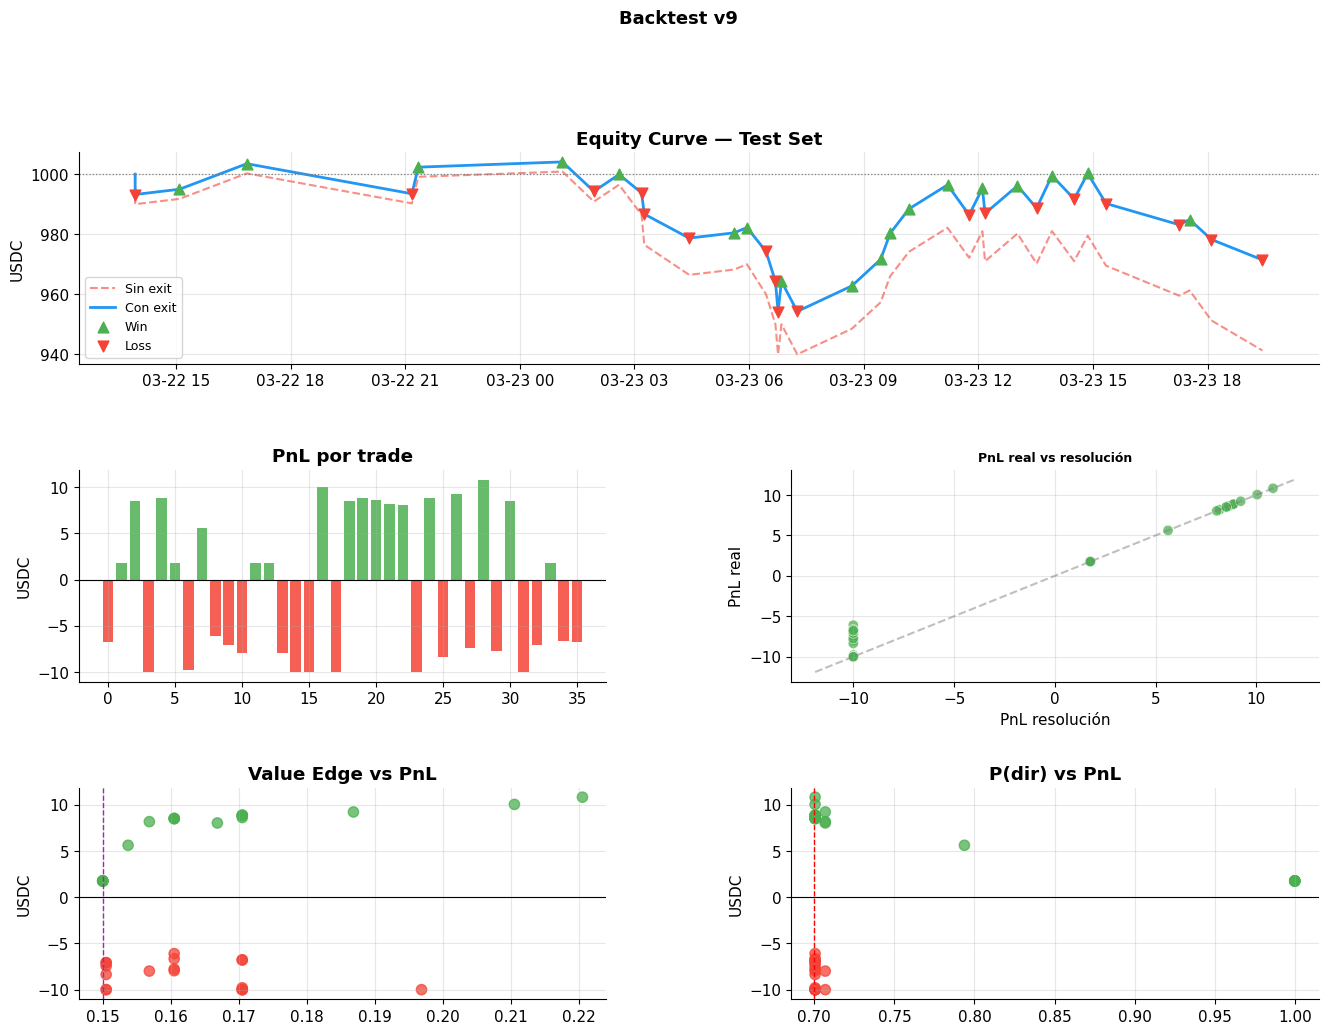

In [90]:
# =============================================================================
# 10. GRÁFICOS
# =============================================================================
if not trade_log.empty:
    fig = plt.figure(figsize=(16, 11))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.35)

    ax = fig.add_subplot(gs[0, :])
    if not trade_log_no.empty:
        ax.plot(equity_no.index, equity_no.values,
                color='#F44336', lw=1.5, alpha=0.6, ls='--', label='Sin exit')
    ax.plot(equity.index, equity.values, color='#2196F3', lw=2, label='Con exit')
    ax.axhline(CFG['INIT_CAPITAL'], ls=':', color='gray', lw=0.9)
    ax.scatter(trade_log[trade_log['pnl']>0]['timestamp'],
               trade_log[trade_log['pnl']>0]['equity'],
               marker='^', s=60, color='#4CAF50', zorder=5, label='Win')
    ax.scatter(trade_log[trade_log['pnl']<=0]['timestamp'],
               trade_log[trade_log['pnl']<=0]['equity'],
               marker='v', s=60, color='#F44336', zorder=5, label='Loss')
    ax.set_title('Equity Curve — Test Set', fontweight='bold')
    ax.set_ylabel('USDC'); ax.legend(fontsize=9)

    ax = fig.add_subplot(gs[1, 0])
    colors_bar = ['#4CAF50' if p > 0 else '#F44336' for p in trade_log['pnl']]
    ax.bar(range(len(trade_log)), trade_log['pnl'].values, color=colors_bar, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('PnL por trade', fontweight='bold'); ax.set_ylabel('USDC')

    ax = fig.add_subplot(gs[1, 1])
    c_arr = ['#4CAF50' if p >= r else '#F44336'
             for p, r in zip(trade_log['pnl'], trade_log['pnl_at_resolution'])]
    ax.scatter(trade_log['pnl_at_resolution'], trade_log['pnl'],
               c=c_arr, alpha=0.75, s=55, edgecolors='white', lw=0.5)
    lim = max(abs(trade_log[['pnl','pnl_at_resolution']].values).max() * 1.1, 1)
    ax.plot([-lim, lim], [-lim, lim], '--', color='gray', alpha=0.5)
    ax.set_title('PnL real vs resolución', fontsize=9, fontweight='bold')
    ax.set_xlabel('PnL resolución'); ax.set_ylabel('PnL real')

    ax = fig.add_subplot(gs[2, 0])
    c2 = ['#4CAF50' if p > 0 else '#F44336' for p in trade_log['pnl']]
    ax.scatter(trade_log['value_edge_entry'], trade_log['pnl'], c=c2, alpha=0.75, s=55)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(CFG['VALUE_EDGE'], ls='--', color='#9C27B0', lw=1)
    ax.set_title('Value Edge vs PnL', fontweight='bold'); ax.set_ylabel('USDC')

    ax = fig.add_subplot(gs[2, 1])
    ax.scatter(trade_log['p_entry'], trade_log['pnl'], c=c2, alpha=0.75, s=55)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(CFG['MIN_P'], ls='--', color='red', lw=1)
    ax.set_title('P(dir) vs PnL', fontweight='bold'); ax.set_ylabel('USDC')

    plt.suptitle('Backtest v9', fontsize=13, fontweight='bold', y=1.01)
    plt.show()


---
## 12 · Validación Monte Carlo (Random Market Splits)

En cada iteración:
1. Barajar todos los mercados
2. Asignar mercados completos a train / val / test (nunca partidos)
3. Filtrar snapshots de train/val a la ventana de operación ± margen
4. Entrenar modelo nuevo + calibrar
5. Scoring + backtest (1 trade/mercado)
6. Registrar métricas


In [91]:
# =============================================================================
# 12. VALIDACIÓN MONTE CARLO
# =============================================================================

N_ITERS   = 20
TRAIN_PCT = 0.55
VAL_PCT   = 0.15

P_LO = CFG['TRAIN_PROGRESS_LO']
P_HI = CFG['TRAIN_PROGRESS_HI']
rng  = np.random.RandomState(SEED)

all_markets = fe['market_slug'].unique().tolist()
N_mkts      = len(all_markets)
n_tr_m      = int(N_mkts * TRAIN_PCT)
n_va_m      = int(N_mkts * VAL_PCT)

print(f"Monte Carlo: {N_ITERS} iteraciones")
print(f"  Mercados: {N_mkts} total | train {n_tr_m} | val {n_va_m} | test {N_mkts - n_tr_m - n_va_m}")
print(f"  Filtro progreso: [{P_LO}, {P_HI}]")
print(f"  1 trade/mercado")
print(f"\n{'Iter':>4} {'N':>5} {'WR':>6} {'PnL':>8} {'ROI':>8} {'PF':>6} {'MDD':>8} {'Sharpe':>7}")
print("─" * 58)

mc_results = []

for it in range(N_ITERS):
    shuffled = rng.permutation(all_markets)
    mc_tr_m = shuffled[:n_tr_m].tolist()
    mc_va_m = shuffled[n_tr_m : n_tr_m + n_va_m].tolist()
    mc_te_m = shuffled[n_tr_m + n_va_m :].tolist()

    mc_tr = fe[fe['market_slug'].isin(mc_tr_m)]
    mc_va = fe[fe['market_slug'].isin(mc_va_m)]
    mc_te = fe[fe['market_slug'].isin(mc_te_m)]

    # Filtrar train/val por ventana de operación
    mc_tr_f = mc_tr[(mc_tr['market_progress'] >= P_LO) & (mc_tr['market_progress'] <= P_HI)]
    mc_va_f = mc_va[(mc_va['market_progress'] >= P_LO) & (mc_va['market_progress'] <= P_HI)]

    if len(mc_tr_f) < 50 or len(mc_va_f) < 20:
        mc_results.append(dict(n=0, wr=np.nan, pnl=0, roi=0, pf=0, mdd=0, sharpe=0))
        continue

    mc_med = pd.DataFrame(mc_tr_f[FEATURES].values, columns=FEATURES).median()
    X_mc_tr = to_matrix(mc_tr_f, mc_med); y_mc_tr = mc_tr_f['y'].values
    X_mc_va = to_matrix(mc_va_f, mc_med); y_mc_va = mc_va_f['y'].values

    # Entrenar
    if USE_XGB:
        dm_tr = xgb.DMatrix(X_mc_tr, label=y_mc_tr, feature_names=FEATURES)
        dm_va = xgb.DMatrix(X_mc_va, label=y_mc_va, feature_names=FEATURES)
        mc_bst = xgb.train(
            xgb_params, dm_tr, num_boost_round=800,
            evals=[(dm_va, 'v')], early_stopping_rounds=50, verbose_eval=False,
        )
        class _X:
            def __init__(s, b): s.bst = b
            def predict_proba(s, X):
                p = s.bst.predict(xgb.DMatrix(X, feature_names=FEATURES))
                return np.column_stack([1-p, p])
        mc_raw = _X(mc_bst)
    else:
        mc_raw = HistGradientBoostingClassifier(
            max_iter=600, learning_rate=0.03, max_depth=3,
            min_samples_leaf=40, l2_regularization=2.0,
            random_state=SEED + it,
        )
        mc_raw.fit(X_mc_tr, y_mc_tr)

    # Calibrar
    p_mc_va = mc_raw.predict_proba(X_mc_va)[:, 1]
    mc_iso = IsotonicRegression(out_of_bounds='clip')
    mc_iso.fit(p_mc_va, y_mc_va)

    class _C:
        def __init__(s, b, c): s.b = b; s.c = c
        def predict_proba(s, X):
            p = s.c.transform(s.b.predict_proba(X)[:, 1])
            return np.column_stack([1-p, p])
    mc_model = _C(mc_raw, mc_iso)

    # Scoring sobre test completo (sin filtro de progreso)
    mc_te = mc_te.copy()
    X_mc_te = to_matrix(mc_te, mc_med)
    mc_te['p_up']   = mc_model.predict_proba(X_mc_te)[:, 1]
    mc_te['p_down'] = 1.0 - mc_te['p_up']
    mc_te['ev_up']   = mc_te['p_up']   * mc_te['up_win_net']   + mc_te['p_down'] * mc_te['up_loss_net']
    mc_te['ev_down'] = mc_te['p_down'] * mc_te['down_win_net'] + mc_te['p_up']   * mc_te['down_loss_net']
    mc_te['value_edge_up']   = mc_te['p_up']   - mc_te['up_ask_p_1']
    mc_te['value_edge_down'] = mc_te['p_down'] - mc_te['down_ask_p_1']

    # Backtest (1 trade/mercado)
    mc_tl, mc_eq = run_backtest(mc_te, CFG)

    if mc_tl.empty:
        mc_results.append(dict(n=0, wr=np.nan, pnl=0, roi=0, pf=0, mdd=0, sharpe=0))
        print(f"  {it:>3}  sin trades")
        continue

    # Verificar 1 trade/mercado
    assert mc_tl['market'].duplicated().sum() == 0, f"Iter {it}: trades duplicados"

    n   = len(mc_tl); wr = (mc_tl['pnl'] > 0).mean()
    pnl = mc_tl['pnl'].sum(); roi = pnl / CFG['INIT_CAPITAL']
    gp  = mc_tl[mc_tl['pnl']>0]['pnl'].sum()
    gl  = mc_tl[mc_tl['pnl']<0]['pnl'].abs().sum()
    pf  = gp / (gl + 1e-9)
    eq  = mc_eq.values; rm = np.maximum.accumulate(eq)
    mdd = ((eq - rm) / rm).min()
    pa  = mc_tl['pnl'].values
    sh  = pa.mean() / (pa.std() + 1e-9) * np.sqrt(n)

    mc_results.append(dict(n=n, wr=wr, pnl=pnl, roi=roi, pf=pf, mdd=mdd, sharpe=sh))
    print(f"  {it:>3} {n:>5} {wr:>5.1%} {pnl:>+7.2f} {roi:>+7.2%} {pf:>5.2f} {mdd:>+7.2%} {sh:>6.2f}")

mc_df = pd.DataFrame(mc_results)
mc_valid = mc_df[mc_df['n'] > 0]

print(f"\n{'═'*58}")
print(f"  MONTE CARLO — RESUMEN ({len(mc_valid)}/{N_ITERS} iters con trades)")
print(f"{'═'*58}")

if len(mc_valid) > 0:
    for col, label, fmt in [
        ('n',      'N trades',      '.1f'),
        ('wr',     'Win Rate',      '.1%'),
        ('pnl',    'PnL (USDC)',    '+.2f'),
        ('roi',    'ROI',           '+.2%'),
        ('pf',     'Profit Factor', '.2f'),
        ('mdd',    'Max Drawdown',  '.2%'),
        ('sharpe', 'Sharpe',        '.2f'),
    ]:
        v = mc_valid[col].dropna()
        print(f"  {label:<16} media={v.mean():{fmt}}  med={v.median():{fmt}}  "
              f"std={v.std():{fmt}}  [p10={v.quantile(0.1):{fmt}}, p90={v.quantile(0.9):{fmt}}]")

    pct_profit = (mc_valid['pnl'] > 0).mean()
    print(f"\n  Iteraciones rentables: {pct_profit:.0%} ({(mc_valid['pnl']>0).sum()}/{len(mc_valid)})")


Monte Carlo: 20 iteraciones
  Mercados: 1194 total | train 656 | val 179 | test 359
  Filtro progreso: [0.05, 0.45]
  1 trade/mercado

Iter     N     WR      PnL      ROI     PF      MDD  Sharpe
──────────────────────────────────────────────────────────
    0    14 64.3%  +13.66  +1.37%  1.31  -1.69%   0.48
    1    19 52.6%  -47.57  -4.76%  0.43  -6.20%  -1.66
    2    93 63.4%   +4.77  +0.48%  1.02  -4.44%   0.08
    3   129 60.5%  +29.54  +2.95%  1.08  -6.82%   0.40
    4    56 64.3%  +55.94  +5.59%  1.30  -3.01%   0.93
    5     9 55.6%   +8.66  +0.87%  1.32  -2.04%   0.42
    6    66 56.1%  +11.18  +1.12%  1.04  -7.06%   0.15
    7    56 66.1%  +25.62  +2.56%  1.18  -4.37%   0.58
    8    44 59.1%  -60.40  -6.04%  0.64  -6.73%  -1.35
    9    16 68.8%  -13.87  -1.39%  0.70  -2.11%  -0.58
   10    42 61.9%   -5.50  -0.55%  0.95  -4.49%  -0.14
   11    64 50.0%  -37.90  -3.79%  0.87  -6.59%  -0.56
   12   184 53.8%  +53.44  +5.34%  1.09 -11.18%   0.52
   13   111 57.7%  -39.11  -3.9

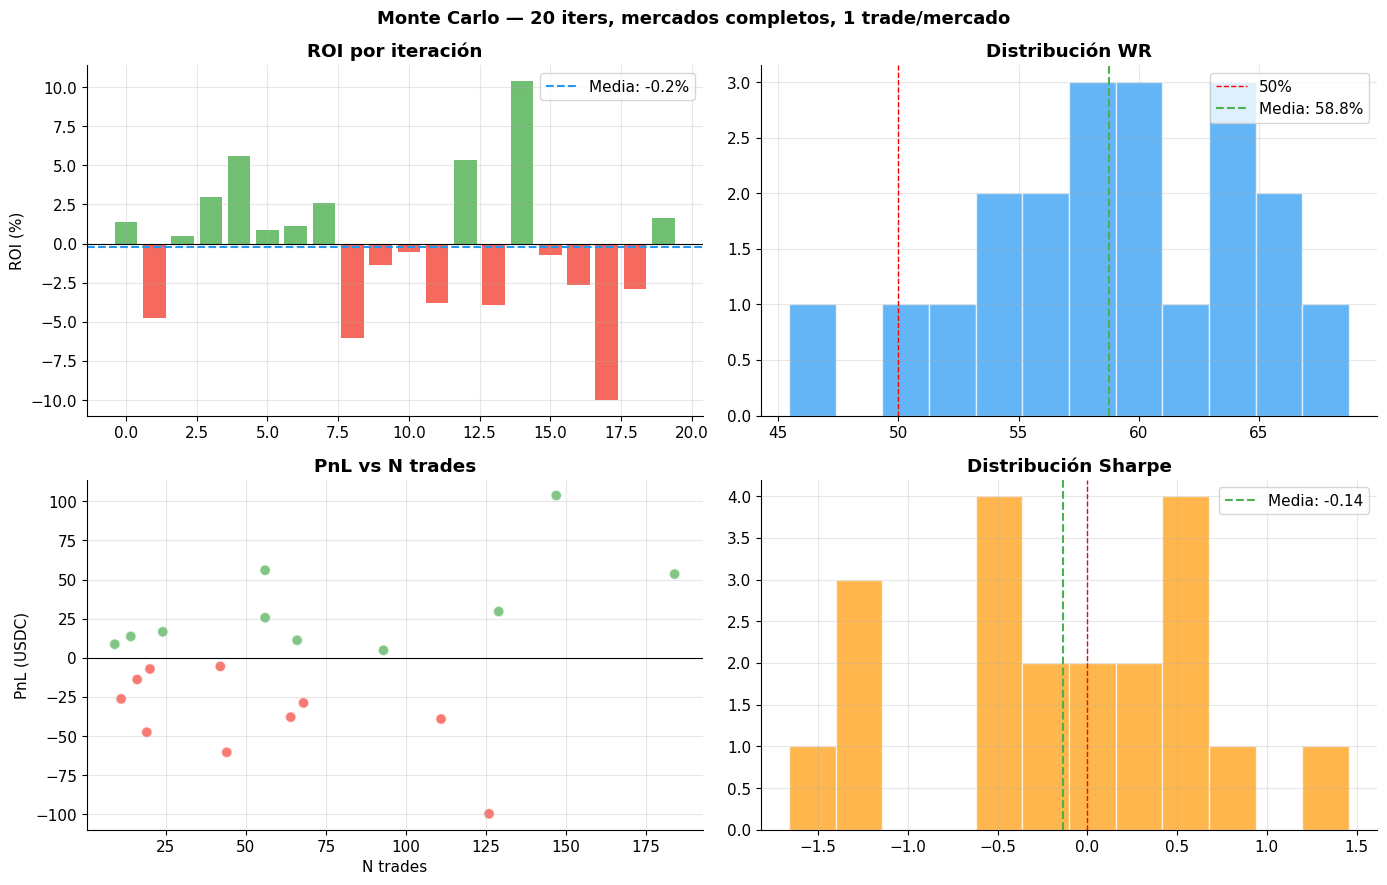

In [92]:
# =============================================================================
# 12b. GRÁFICOS MONTE CARLO
# =============================================================================
if len(mc_valid) > 2:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0, 0]
    c_roi = ['#4CAF50' if v > 0 else '#F44336' for v in mc_valid['roi']]
    ax.bar(range(len(mc_valid)), mc_valid['roi'].values * 100, color=c_roi, alpha=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(mc_valid['roi'].mean()*100, ls='--', color='#2196F3', lw=1.5,
               label=f"Media: {mc_valid['roi'].mean():.1%}")
    ax.set_title('ROI por iteración', fontweight='bold')
    ax.set_ylabel('ROI (%)'); ax.legend()

    ax = axes[0, 1]
    ax.hist(mc_valid['wr']*100, bins=12, color='#2196F3', alpha=0.7, edgecolor='white')
    ax.axvline(50, ls='--', color='red', lw=1, label='50%')
    ax.axvline(mc_valid['wr'].mean()*100, ls='--', color='#4CAF50', lw=1.5,
               label=f"Media: {mc_valid['wr'].mean():.1%}")
    ax.set_title('Distribución WR', fontweight='bold'); ax.legend()

    ax = axes[1, 0]
    c_pnl = ['#4CAF50' if v > 0 else '#F44336' for v in mc_valid['pnl']]
    ax.scatter(mc_valid['n'], mc_valid['pnl'], c=c_pnl, alpha=0.7, s=60, edgecolors='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title('PnL vs N trades', fontweight='bold')
    ax.set_xlabel('N trades'); ax.set_ylabel('PnL (USDC)')

    ax = axes[1, 1]
    ax.hist(mc_valid['sharpe'], bins=12, color='#FF9800', alpha=0.7, edgecolor='white')
    ax.axvline(0, ls='--', color='red', lw=1)
    ax.axvline(mc_valid['sharpe'].mean(), ls='--', color='#4CAF50', lw=1.5,
               label=f"Media: {mc_valid['sharpe'].mean():.2f}")
    ax.set_title('Distribución Sharpe', fontweight='bold'); ax.legend()

    plt.suptitle(f'Monte Carlo — {N_ITERS} iters, mercados completos, 1 trade/mercado',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


---
## 13 · Resumen

In [93]:
# =============================================================================
# 13. RESUMEN
# =============================================================================
D = '=' * 58
print(D)
print('  RESUMEN — Polymarket BTC XGBoost v9')
print(D)
print(f"  Modelo         : {'XGBoost' if USE_XGB else 'HistGBT'} (max_depth=3, mcw=40)")
print(f"  Features       : {len(FEATURES)}")
print(f"  Filtro train   : progress ∈ [{CFG['TRAIN_PROGRESS_LO']}, {CFG['TRAIN_PROGRESS_HI']}]")
print(f"  Test AUC       : {roc_auc_score(y_te, MODEL.predict_proba(X_te)[:,1]):.4f}")
print(f"  Filtros entrada: MIN_P≥{CFG['MIN_P']}  VE≥{CFG['VALUE_EDGE']}")
print(f"  Ventana entrada: progress ∈ [{CFG['ENTRY_LO']}, {CFG['ENTRY_HI']}]")
print(f"  Exit           : Model-Flip < {CFG['FLIP_THRESH']}")
print(f"  1 trade/mercado: ✓")

if not trade_log.empty:
    print(f"\n  {'Métrica':<18} {'Con exit':>10} {'Sin exit':>10}")
    print(f"  {'─'*40}")
    print(f"  {'N trades':<18} {len(trade_log):>10} {len(trade_log_no):>10}")
    print(f"  {'Win Rate':<18} {(trade_log['pnl']>0).mean():>9.1%} {(trade_log_no['pnl']>0).mean():>9.1%}")
    print(f"  {'PnL Total':<18} {trade_log['pnl'].sum():>+9.2f} {trade_log_no['pnl'].sum():>+9.2f}")

if len(mc_valid) > 0:
    print(f"\n  Monte Carlo ({len(mc_valid)} iters):")
    print(f"    ROI medio:    {mc_valid['roi'].mean():+.2%}")
    print(f"    WR media:     {mc_valid['wr'].mean():.1%}")
    print(f"    % rentable:   {(mc_valid['pnl']>0).mean():.0%}")
    print(f"    Sharpe medio: {mc_valid['sharpe'].mean():.2f}")
print(D)


  RESUMEN — Polymarket BTC XGBoost v9
  Modelo         : XGBoost (max_depth=3, mcw=40)
  Features       : 16
  Filtro train   : progress ∈ [0.05, 0.45]
  Test AUC       : 0.8076
  Filtros entrada: MIN_P≥0.7  VE≥0.15
  Ventana entrada: progress ∈ [0.1, 0.4]
  Exit           : Model-Flip < 0.2
  1 trade/mercado: ✓

  Métrica              Con exit   Sin exit
  ────────────────────────────────────────
  N trades                   36         36
  Win Rate               50.0%     50.0%
  PnL Total             -28.59    -58.79

  Monte Carlo (20 iters):
    ROI medio:    -0.22%
    WR media:     58.8%
    % rentable:   50%
    Sharpe medio: -0.14
